# Covid-19 in South Korea

- To which region side of Seoul did virus spread the fastest and what might impacted it?
- Is treatment at home is effective as in hospital?
- In average how many people is infected by one person?

## Dataset import (format: alt + shift + F)

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functions_sandbox import cleaner

path = r"D:\IT_projects\Turing_Colledge\Modul1\Sprint4\project"

case = pd.read_csv(path + r"\Case.csv")
patient_info = pd.read_csv(path + r"\PatientInfo.csv")
policy = pd.read_csv(path + r"\Policy.csv")
region = pd.read_csv(path + r"\Region.csv")
search_trend = pd.read_csv(path + r"\SearchTrend.csv")
seoul_floating = pd.read_csv(path + r"\SeoulFloating.csv")
time = pd.read_csv(path + r"\Time.csv")
time_age = pd.read_csv(path + r"\TimeAge.csv")
time_gender = pd.read_csv(path + r"\TimeGender.csv")
time_province = pd.read_csv(path + r"\TimeProvince.csv")
weather = pd.read_csv(path + r"\Weather.csv")

all_tables = [
    {"case": case},
    {"patient_info": patient_info},
    {"policy": policy},
    {"region": region},
    {"search_trend": search_trend},
    {"seoul_floating": seoul_floating},
    {"time": time},
    {"time_age": time_age},
    {"time_gender": time_gender},
    {"time_province": time_province},
    {"weather": weather},
]

### First look

In [32]:
shape_table = [(list(table.keys())[0], list(table.values())[0].shape) for table in all_tables]
for look in shape_table:
    print(look)

('case', (174, 8))
('patient_info', (5165, 14))
('policy', (61, 7))
('region', (244, 12))
('search_trend', (1642, 5))
('seoul_floating', (1084800, 7))
('time', (163, 7))
('time_age', (1089, 5))
('time_gender', (242, 5))
('time_province', (2771, 6))
('weather', (26271, 10))


In [33]:
weather.head(3)
#case: latitude, longitude to float;
#patient_info: many NaNs in various columns;
#policy: difficult to analise;
#region: very clean to analyse;
#search_trend: wrong dtype for date; nice table to analyse;
#seoul_floating: wrong dtype for date; what is fp_num?, birth_year?;
#time: should time be days?; dtype for date is wrong;
#time_age: wrong dtype for date; strange time; 
#time_gender: dtype for date; looks like random table;
#time_province: dtype for date; decent;
#weather: dtype for date; some of NaNs exists; interesting perspective to analyse;

,code,province,date,avg_temp,min_temp,max_temp,precipitation,max_wind_speed,most_wind_direction,avg_relative_humidity
0,10000,Seoul,2016-01-01,1.2,-3.3,4.0,0.0,3.5,90.0,73.0
1,11000,Busan,2016-01-01,5.3,1.1,10.9,0.0,7.4,340.0,52.1
2,12000,Daegu,2016-01-01,1.7,-4.0,8.0,0.0,3.7,270.0,70.5


In [34]:
time_province.info()
# policy["gov_policy"].unique()
# weather.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       2771 non-null   object
 1   time       2771 non-null   int64 
 2   province   2771 non-null   object
 3   confirmed  2771 non-null   int64 
 4   released   2771 non-null   int64 
 5   deceased   2771 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 130.0+ KB


In [109]:
clean_time_province = cleaner(time_province, info=False)
clean_time_province["date"] = pd.to_datetime(clean_time_province["date"])
clean_time_province.sort_values(by="date", ascending=True, inplace=True)
clean_time_province["week"] = clean_time_province["date"].dt.isocalendar().week
four = clean_time_province[clean_time_province["province"].isin(["Seoul", "Jeju-do"])]
# clean_time_province.head(5)
four

,date,time,province,confirmed,released,deceased,week
0,2020-01-20,16,Seoul,0,0,0,4
16,2020-01-20,16,Jeju-do,0,0,0,4
33,2020-01-21,16,Jeju-do,0,0,0,4
17,2020-01-21,16,Seoul,0,0,0,4
50,2020-01-22,16,Jeju-do,0,0,0,4
...,...,...,...,...,...,...,...
2720,2020-06-28,0,Seoul,1298,923,7,26
2753,2020-06-29,0,Jeju-do,19,16,0,27
2737,2020-06-29,0,Seoul,1305,942,7,27
2754,2020-06-30,0,Seoul,1312,985,7,27


## EDA (Exploratory Data Analysis)

### Virus spreading in provinces

In [111]:
unique_provinces = clean_time_province["province"].unique()
grouped_provinces = (
    clean_time_province.groupby("province")
    .agg({"confirmed": "sum", "released": "sum", "deceased": "sum"})
    .sort_values(by="confirmed", ascending=False)
    .reset_index()
)
date_start = clean_time_province["date"].min()
date_end = clean_time_province["date"].max()

print(f"There are {len(unique_provinces)} unique provinces\n")
print(f"Date when tracking was started: {date_start}")
print(f"Date when tracking was ended: {date_end}\n")
print(grouped_provinces)

There are 17 unique provinces

Date when tracking was started: 2020-01-20 00:00:00
Date when tracking was ended: 2020-06-30 00:00:00

             province  confirmed  released  deceased
0               Daegu     807506    600431     17624
1    Gyeongsangbuk-do     161079    117042      5393
2               Seoul      81923     48687       298
3         Gyeonggi-do      81059     52096      1600
4   Chungcheongnam-do      16780     12814         0
5             Incheon      16645      8904        16
6               Busan      16341     12678       299
7    Gyeongsangnam-do      13860     10549         0
8          Gangwon-do       5908      4076       225
9   Chungcheongbuk-do       5801      4187         0
10              Ulsan       5269      3872        91
11            Daejeon       5217      3388        58
12             Sejong       5111      3629         0
13            Gwangju       3359      2663         0
14       Jeollabuk-do       2108      1489         0
15       Jeollanam

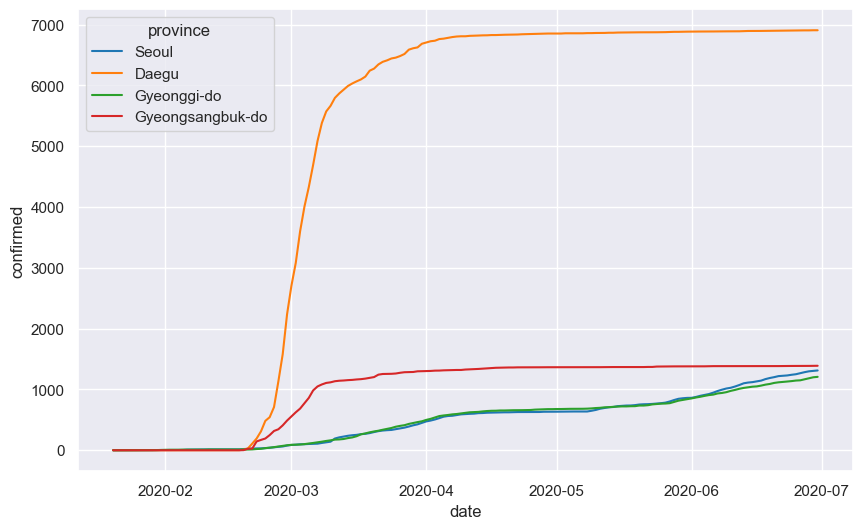

In [112]:
top_names = list(grouped_provinces["province"][:4])
top_four = clean_time_province[clean_time_province["province"].isin(top_names)]

sns.set_style("darkgrid")
sns.set_context("notebook")
plt.figure(figsize=(10, 6))
sns.lineplot(data=top_four, x="date", y=clean_time_province["confirmed"], hue="province")

plt.show()